# 여러 영상 검색 RAG: 근거 프레임으로 OpenAI 답변 만들기

비디오 검색 RAG는 질문과 가까운 프레임 설명을 Vector DB에서 찾고, 검색된 설명만 근거로 답을 생성하는 흐름이다. 이 실습은 아홉 영상의 공통 Chroma collection을 검색하고, LLM이 선택한 `evidence_rank`를 실제 DB metadata에 연결한다.


## 전체 처리 흐름

LLM은 자연어 답변과 근거 순위만 결정한다. `video_id`, `frame_path`, `timestamp_sec`처럼 원본이 이미 알고 있는 값은 생성시키지 않는다. 이렇게 하면 자연스러운 답변과 출처 정보를 분리하여 출처 환각을 줄일 수 있다.

```mermaid
flowchart TD
    A["05의 mixkit_9_v1<br/>Chroma collection"] --> D["chunk 후보 over-fetch"]
    Q["사용자 질문"] --> B["같은 OpenAI embedding model"]
    B --> D
    D --> E["frame_id 중복 제거"]
    E --> F["rank가 붙은 top-k context"]
    F --> G["ChatOpenAI:<br/>found·answer·evidence_rank"]
    G --> H["evidence_rank 선택"]
    E --> H
    H --> I["DB metadata에서<br/>video·frame·timestamp 결정"]
    I --> J["답변·영상·근거 프레임 표시"]
```


## 실행 환경과 API 설정

05를 먼저 실행해 `mixkit_9_v1` Chroma collection을 만들어야 한다. 질문 embedding과 ChatOpenAI 답변 생성은 OpenAI API를 호출하므로 사용량에 따른 비용이 발생한다.

```bash
pip install chromadb==1.5.9 langchain-openai==1.5.2 python-dotenv==1.2.3 pydantic pandas pillow matplotlib
```

실제 key는 `.env`에서 불러오며 source나 출력에 표시하지 않는다. 이 교안에는 `gpt-5.6-luna`로 대표 질문과 11개 평가 질문을 실제 실행한 결과가 저장되어 있다.


In [1]:
# %pip install chromadb==1.5.9 langchain-openai==1.5.2 python-dotenv==1.2.3 pydantic pandas pillow matplotlib

  Using cached langchain_openai-1.5.2-py3-none-any.whl.metadata (3.4 kB)
Using cached langchain_openai-1.5.2-py3-none-any.whl (124 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 28.7 MB/s  0:00:00
  Attempting uninstall: openai
    Found existing installation: openai 2.15.0
    Uninstalling openai-2.15.0:
      Successfully uninstalled openai-2.15.0
  Attempting uninstall: langchain-openai━━━━━━━━ 0/2 [openai]
    Found existing installation: langchain-openai 1.6.0/2 [openai]
    Uninstalling langchain-openai-1.6.0:━━━━ 0/2 [openai]
      Successfully uninstalled langchain-openai-1.6.0m0/2 [openai]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [langchain-openai]
Note: you may need to restart the kernel to use updated packages.


## Chroma collection과 OpenAI model 준비하기

질문 embedding은 05에서 저장한 caption embedding과 같은 model을 사용해야 한다. `MIN_SIMILARITY`는 검색 결과가 corpus와 충분히 가까운지 판단하는 수업용 기준이다. 절대적인 정답 기준이 아니므로 실제 positive·negative 결과를 관찰한 뒤 조정한다.


In [2]:
import os
from pathlib import Path

import chromadb
from dotenv import find_dotenv, load_dotenv
from langchain_openai import ChatOpenAI, OpenAIEmbeddings

ENV_PATH = find_dotenv(usecwd=True)
load_dotenv(ENV_PATH)

CORPUS_ID = 'mixkit_9_v1'
ARTIFACT_ROOT = Path('artifacts/multimodal_rag') / CORPUS_ID
COMMENT_DIR = ARTIFACT_ROOT / 'comments'
VIDEO_MANIFEST_PATH = ARTIFACT_ROOT / 'video_manifest.jsonl'
FRAME_MANIFEST_PATH = ARTIFACT_ROOT / 'frame_manifest.jsonl'
CHROMA_DIR = ARTIFACT_ROOT / 'chroma'
COLLECTION_NAME = 'video_frame_descriptions_openai_mixkit9_v1'
EMBEDDING_MODEL_ID = os.getenv('OPENAI_EMBEDDING_MODEL') or 'text-embedding-3-small'
CHAT_MODEL_ID = os.getenv('OPENAI_CHAT_MODEL') or 'gpt-5.6-luna'
MIN_SIMILARITY = 0.25 # 최소 유사도 점수

chroma_client = chromadb.PersistentClient(path=str(CHROMA_DIR))

# 프레임 이미지 54개의 설명을 임베딩해서 저장한 VectorDB Load
frame_collection = chroma_client.get_collection(name=COLLECTION_NAME)

# 사용자 입력을 임베딩 하기 위한 용도
embedding_model = OpenAIEmbeddings(model=EMBEDDING_MODEL_ID)

# Vector DB 검색 결과(근거)를 이용하여 메시지를 생성할 LLM
# reasoning_effort : 추론 정도
chat_model = ChatOpenAI(model=CHAT_MODEL_ID, reasoning_effort='low')

print(f'corpus_id={CORPUS_ID}')
print(f'collection_count={frame_collection.count()}')
print(f'embedding_model={EMBEDDING_MODEL_ID}')
print(f'chat_model={CHAT_MODEL_ID}')
print(f'min_similarity={MIN_SIMILARITY}')


corpus_id=mixkit_9_v1
collection_count=55
embedding_model=text-embedding-3-small
chat_model=gpt-5.6-luna
min_similarity=0.25


## 질문마다 서로 다른 top-k 프레임 검색하기

상세 설명 하나가 여러 chunk로 나뉘므로 필요한 결과 수보다 많은 chunk를 먼저 가져온다. 가까운 순서대로 처음 등장한 `frame_id`만 남기면 top-k가 서로 다른 실제 장면으로 구성된다.


In [3]:
def retrieve_unique_frames(question: str, top_k: int = 4, overfetch_factor: int = 5):

    question_embedding = embedding_model.embed_query(question)
    candidate_count = min(
        frame_collection.count(),
        max(top_k, top_k * overfetch_factor),
    )

    raw_result = frame_collection.query(
        query_embeddings=[question_embedding],
        n_results=candidate_count,
        include=['documents', 'metadatas', 'distances'],
    )

    results = []
    seen_frame_ids = set()
    candidates = zip(
        raw_result['ids'][0],
        raw_result['documents'][0],
        raw_result['metadatas'][0],
        raw_result['distances'][0],
    )
    for chunk_id, text, metadata, distance in candidates:
        if metadata['frame_id'] in seen_frame_ids:
            continue
        seen_frame_ids.add(metadata['frame_id'])
        results.append({
            'chunk_id': chunk_id,
            'text': text,
            'metadata': metadata,
            'distance': float(distance),
            'similarity': 1.0 - float(distance),
        })
        if len(results) == top_k:
            break
    return results

## LLM이 생성할 구조 제한하기

Structured output은 모델 응답을 정해진 필드로 제한하는 방식이다. `found`는 근거 존재 여부, `answer`는 질문에 대한 짧은 답, `evidence_rank`는 검색 결과 중 선택한 순위이다. 영상 파일명이나 프레임 경로는 LLM 출력에 포함하지 않는다.


In [4]:
from pydantic import BaseModel, Field

class RagDecision(BaseModel):

    found: bool = Field(description='검색된 설명에 질문의 답이 직접 있으면 true이다.')
    answer: str = Field(description='검색 근거만 사용한 짧은 한국어 답변이다.')
    evidence_rank: int | None = Field(
        description='found가 true이면 1부터 시작하는 근거 rank이고, false이면 null이다.'
    )

# Chat Model에게 답변 구조를 등록
decision_model = chat_model.with_structured_output(RagDecision)


## 검색과 답변을 하나의 RAG 함수로 연결하기

Context에는 rank, 영상 ID, 시각과 설명 chunk를 넣어 모델이 어떤 근거를 선택했는지 밝히게 한다. 모델이 반환한 rank가 범위를 벗어나거나 top-1 similarity가 임계값보다 낮으면 근거 없음으로 처리한다. 최종 영상·프레임 정보는 선택한 검색 결과의 metadata에서 코드가 가져온다.


In [5]:
def answer_video_question(question: str, top_k: int = 4):

    # 1단계는 질문과 가까운 서로 다른 실제 프레임을 검색하는 과정이다.
    search_results = retrieve_unique_frames(question, top_k=top_k)
    context = '\n\n'.join( # LLM에게 보내는 메시지 (RAG)
        (
            f"Rank {rank}\n"
            f"video_id: {result['metadata']['video_id']}\n"
            f"timestamp_sec: {float(result['metadata']['timestamp_sec']):.2f}\n"
            f"description: {result['text']}"
        )
        for rank, result in enumerate(search_results, start=1)
    )

    # 2단계는 rank가 붙은 검색 context만 LLM에 전달해 구조화 판단을 받는 과정이다. (LangChain)
    decision = decision_model.invoke([
        (
            'system',
            '검색된 프레임 설명만 사용해 답한다. 답이 직접 없으면 found=false로 판단한다. '
            'found=true이면 답을 뒷받침하는 하나의 evidence_rank를 선택한다.',
        ),
        ('human', f'질문: {question}\n\n검색 결과:\n{context}'),
    ])

    # similarity 기준과 rank 범위는 LLM이 아닌 코드가 검증한다.
    valid_rank = (
        decision.evidence_rank is not None
        and 1 <= decision.evidence_rank <= len(search_results)
    )

    selected_candidate = search_results[decision.evidence_rank - 1] if valid_rank else None

    passes_threshold = (
        selected_candidate is not None
        and selected_candidate['similarity'] >= MIN_SIMILARITY # 최소 유사도 점수 0.25
    )

    # 3단계는 LLM 판단, rank 범위와 similarity 기준이 모두 맞을 때만 근거를 채택하는 과정이다.
    found = bool(decision.found and valid_rank and passes_threshold)
    evidence = selected_candidate if found else None

    return {
        'question': question,
        'found': found, # 질문이 프레임 설명에 포함되어 있으면 True
        'answer': decision.answer if found else '검색된 프레임에서 근거를 찾지 못했다.',
        'evidence_rank': decision.evidence_rank if found else None,
        'evidence': evidence,
        'search_results': search_results,
    }

# 함수에 질문을 보내면 답변

## 답변과 검색 근거 표시하기

검색 표는 LLM에 전달된 rank 순서를 그대로 사용한다. 답변 아래에는 선택된 실제 프레임과 로컬 비디오 플레이어를 표시한다. `embed=False`는 MP4 전체를 notebook output에 base64로 저장하지 않고 파일 경로를 참조한다.


In [6]:
import matplotlib.pyplot as plt
from IPython.display import Markdown, Video, display
from PIL import Image

def display_rag_result(result: dict):

    lines = [
        '| rank | video_id | timestamp | similarity | description chunk |',
        '|---:|---|---:|---:|---|',
    ]
    for rank, item in enumerate(result['search_results'], start=1):
        metadata = item['metadata']
        safe_text = item['text'].replace('|', '&#124;').replace('\n', ' ')
        lines.append(
            f"| {rank} | {metadata['video_id']} | {float(metadata['timestamp_sec']):.2f}s | "
            f"{item['similarity']:.4f} | {safe_text} |"
        )

    display(Markdown(f"**질문:** {result['question']}\n\n" + '\n'.join(lines)))
    print(f"found={result['found']}")
    print(f"answer={result['answer']}")

    if result['evidence'] is None:
        return
    metadata = result['evidence']['metadata']
    print(f"evidence_rank={result['evidence_rank']}")
    print(f"video_id={metadata['video_id']}")
    print(f"timestamp_sec={float(metadata['timestamp_sec']):.2f}")
    print(f"frame_path={metadata['frame_path']}")

    with Image.open(Path(metadata['frame_path'])) as image:
        plt.figure(figsize=(8, 4.5))
        plt.imshow(image.convert('RGB'))
        plt.axis('off')
        plt.title(f"{metadata['video_id']} | {float(metadata['timestamp_sec']):.2f}s")
        plt.show()
    display(Video(str(metadata['video_path']), embed=False, html_attributes='controls'))


## 대표 positive 질문 네 개 실행하기

Positive 질문은 corpus 안에 답이 있는 장면을 묻는다. 강아지, 요리, 서핑과 축구처럼 서로 다른 영상의 결과가 선택되는지 확인한다.


**질문:** 강아지가 사람과 같이 있는가?

| rank | video_id | timestamp | similarity | description chunk |
|---:|---|---:|---:|---|
| 1 | dog_ball | 1.04s | 0.2817 | 검은색 큰 개 한 마리와 두 사람이 보인다.   왼쪽 남성은 개 옆에 쪼그려 앉아 있고, 오른쪽 여성도 몸을 낮춘 채 개를 바라보고 있다.   장면은 소나무가 있는 잔디 마당이며, 뒤쪽에 넓은 지붕의 단층 주택과 열린 현관이 보인다.   개는 분홍색 하네스를 착용하고 있고, 여성은 청색과 노란색 체크 셔츠를 입고 있다. |
| 2 | dog_ball | 15.97s | 0.2703 | 남성이 풀밭에 쪼그려 앉아 검은색 개의 몸 쪽에 손을 대고 있으며, 여성은 개를 마주 보고 앉아 손을 내밀고 있다.   개는 두 사람 사이에 서 있고 목에 분홍색 스카프를 하고 있다.   장면은 나무가 있는 잔디밭과 붉은 지붕의 단층 주택 앞에서 펼쳐진다.   남성과 여성은 각각 어두운색과 청색 계열의 체크무늬 셔츠를 입고 있으며, 밝은 햇빛과 분홍색 스카프가 눈에 띈다. |
| 3 | dog_ball | 4.75s | 0.2661 | 검은색 대형견이 화면 앞쪽에 서서 오른쪽에 앉아 있는 여성과 마주 보고 있다.   여성은 손에 분홍색과 보라색 물체를 들고 개 쪽으로 내밀고 있으며, 뒤쪽의 남성도 개 가까이에 있다.   장면은 나무와 잔디가 있는 주택 마당으로, 배경에 기와지붕의 건물과 테라스가 보인다.   개는 분홍색 목걸이를 하고 있고, 여성은 노란색과 파란색 체크무늬 셔츠를 입고 있다. |
| 4 | dog_ball | 12.22s | 0.2524 | 남성과 여성이 검은색 개와 함께 화면 중앙 아래쪽에 있다.   남성은 개의 앞쪽을 손으로 만지고 있고, 여성은 개의 등 쪽에 손을 대고 있다.   장면은 잔디가 깔린 주택 마당으로, 뒤에는 나무와 기와 지붕의 건물이 보인다.   남성은 체크무늬 셔츠를, 여성은 청색과 노란색 체크무늬 셔츠를 입고 있으며 두 사람 모두 몸을 낮추고 있다. |

found=True
answer=네. 강아지가 두 사람과 함께 있습니다.
evidence_rank=1
video_id=dog_ball
timestamp_sec=1.04
frame_path=artifacts/multimodal_rag/mixkit_9_v1/frames/dog_ball/dog_ball_frame0000025.jpg


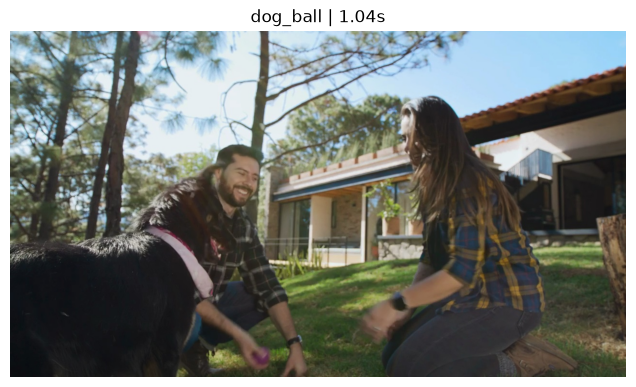

**질문:** 요리사가 음식을 볶고 있는가?

| rank | video_id | timestamp | similarity | description chunk |
|---:|---|---:|---:|---|
| 1 | cooking | 7.80s | 0.2485 | 프라이팬 안에 다진 고기와 기름이 들어 있고, 나무 주걱이 고기를 젓고 있다.   팬은 가스레인지 위에 놓여 있으며 주변에 여러 개의 금속 버너 받침대가 보인다.   팬 가장자리는 사용 흔적이 있는 갈색으로 변색되어 있고, 팬 내부에는 기름이 반짝이는 것이 시각적 특징이다. |
| 2 | dog_ball | 1.04s | 0.1938 | 검은색 큰 개 한 마리와 두 사람이 보인다.   왼쪽 남성은 개 옆에 쪼그려 앉아 있고, 오른쪽 여성도 몸을 낮춘 채 개를 바라보고 있다.   장면은 소나무가 있는 잔디 마당이며, 뒤쪽에 넓은 지붕의 단층 주택과 열린 현관이 보인다.   개는 분홍색 하네스를 착용하고 있고, 여성은 청색과 노란색 체크 셔츠를 입고 있다. |
| 3 | cooking | 0.42s | 0.1710 | 프라이팬 안에 잘게 썬 재료가 담겨 있고, 나무 주걱이 재료를 저으며 움직이고 있다.   팬은 가스레인지 위에 놓여 있으며 아래쪽 버너에서 파란 불꽃이 보인다.   주변에는 여러 개의 화구와 금속으로 된 조리대가 보인다.   팬 가장자리는 사용 흔적이 있는 갈색빛을 띠고, 재료 표면에는 기름기가 반짝인다. |
| 4 | cooking | 6.34s | 0.1615 | 프라이팬에 잘게 썬 양파와 재료가 볶이고 있으며, 나무 주걱이 팬 안쪽에 놓여 있다.   팬은 가스레인지 위에 올려져 있고 주변에 다른 화구와 조리대가 보인다.   팬 바닥에는 기름이 glossy하게 고여 있으며, 양파 가장자리가 갈색으로 익어가는 모습이 보인다. |

found=False
answer=검색된 프레임에서 근거를 찾지 못했다.


**질문:** 서퍼는 파도 위에서 무엇을 하고 있는가?

| rank | video_id | timestamp | similarity | description chunk |
|---:|---|---:|---:|---|
| 1 | surfing | 0.92s | 0.4664 | 바다 위에 여러 명의 서퍼가 보이며, 일부는 파도 위에서 서핑하고 있습니다.   장면은 넓은 바다와 완만하게 솟은 파도가 펼쳐진 곳이며, 멀리 안개 낀 산 능선이 보입니다.   전체적으로 흐린 하늘과 잔잔한 회청색 수면이 이어지고, 왼쪽에는 비교적 큰 초록빛 파도가 형성되어 있습니다. |
| 2 | surfing | 7.42s | 0.4580 | 바다 한가운데에서 서퍼 한 명이 파도를 타고 있다.   서퍼 주변으로 흰 포말이 일며 파도가 길게 부서지고, 왼쪽 먼 곳에는 작은 인물이 보인다.   뒤쪽 수평선에는 안개 낀 산과 해안선이 희미하게 보이며, 전체적으로 푸른 회색빛 바다와 넓은 파도 물결이 펼쳐져 있다. |
| 3 | surfing | 13.89s | 0.3486 | 바다 위에 길게 이어진 큰 파도와 흰 포말이 보인다.   파도가 오른쪽에서 아래쪽 방향으로 부서지며 물결을 만들고, 파도 주변에 작은 어두운 형체가 보인다.   뒤쪽에는 흐릿한 산 능선과 구름 낀 하늘이 있으며, 넓은 수면과 밝은 흰 포말의 대비가 두드러진다. |
| 4 | surfing | 10.64s | 0.3431 | 바다에서 서핑보드 위에 탄 사람이 파도를 타고 있고, 왼쪽 먼 곳에도 작은 서핑보드와 사람이 보인다.   오른쪽의 큰 파도가 하얗게 부서지며 해안 쪽으로 이어지고 있다.   장소는 흐린 하늘 아래의 넓은 바다이며, 뒤쪽 수평선에는 희미한 산과 육지가 보인다.   전체적으로 푸른 회색빛이 감돌고 큰 흰색 파도가 화면의 주요 시각적 특징을 이룬다. |

found=True
answer=서퍼는 파도 위에서 서핑하며 파도를 타고 있다.
evidence_rank=1
video_id=surfing
timestamp_sec=0.92
frame_path=artifacts/multimodal_rag/mixkit_9_v1/frames/surfing/surfing_frame0000022.jpg


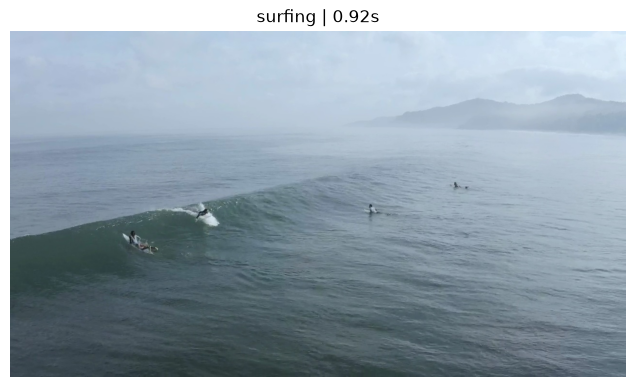

**질문:** 축구 선수는 공으로 무엇을 하고 있는가?

| rank | video_id | timestamp | similarity | description chunk |
|---:|---|---:|---:|---|
| 1 | soccer | 12.37s | 0.4975 | 축구장 위에 여러 명의 사람들이 골대 주변에 서 있다.   일부는 골대 쪽을 바라보며 걷거나 서 있고, 한 사람은 파란색 상의를 입고 공을 들고 있다.   장소는 인조 잔디가 깔린 야외 축구장으로, 뒤편에 높은 그물과 울창한 나무가 보인다.   화면은 지면 가까이에서 촬영되어 잔디가 전경을 크게 차지하며, 골대와 그물이 중앙에 배치되어 있다. |
| 2 | soccer | 3.00s | 0.4863 | 여러 명의 사람들이 축구공 주변에 모여 있고, 초록색 상의를 입은 선수가 공을 바라보고 있다.   선수들은 인조잔디 위에서 공을 차거나 움직이며 경기를 하고 있다.   장소는 철망으로 둘러싸인 야외 축구장이고, 뒤쪽에는 나무와 서 있는 사람이 보인다.   화면 중앙 아래에는 노란색과 파란색 무늬의 축구공이 있으며, 낮은 시점에서 촬영된 장면이다. |
| 3 | soccer | 7.70s | 0.4387 | 여러 사람이 인조 잔디 축구장에서 공을 차며 축구를 하고 있다.   앞쪽에는 회색 상의를 입은 사람이 골대를 향해 서 있고, 왼쪽과 중앙에는 다른 선수들이 움직이고 있다.   배경에는 흰색 축구 골대와 높은 그물망, 나무가 보인다.   낮은 시점에서 촬영되어 잔디가 화면 앞부분을 넓게 차지하는 것이 특징이다. |
| 4 | soccer | 10.03s | 0.4211 | 축구 골대 앞에 성인 두 명과 어린이 한 명이 서 있고, 바닥에는 노란색 축구공이 보인다.   어린이는 공 가까이에 있으며, 성인 두 명은 어린이와 나란히 골대 쪽에 서 있다.   장소는 높은 그물 펜스로 둘러싸인 야외 인조잔디 축구장이고, 뒤편에는 나무들이 있다.   화면 전체에 경기장 그물과 골대가 겹쳐 보이며, 낮은 시점에서 촬영된 점이 특징적이다. |

found=True
answer=축구 선수들은 공을 차거나 움직이며 축구를 하고 있다.
evidence_rank=2
video_id=soccer
timestamp_sec=3.00
frame_path=artifacts/multimodal_rag/mixkit_9_v1/frames/soccer/soccer_frame0000090.jpg


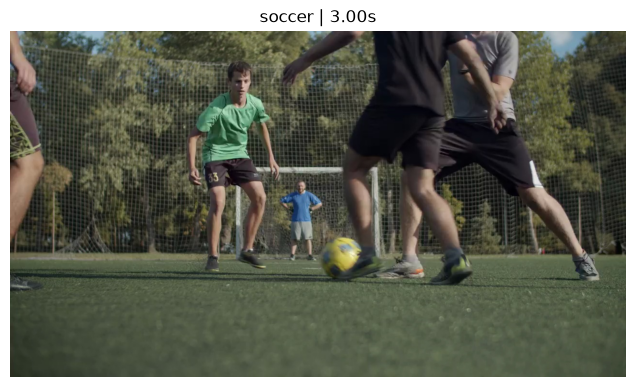

In [8]:
POSITIVE_QUESTIONS = [
    '강아지가 사람과 같이 있는가?',
    '요리사가 음식을 볶고 있는가?',
    '서퍼는 파도 위에서 무엇을 하고 있는가?',
    '축구 선수는 공으로 무엇을 하고 있는가?',
]

for question in POSITIVE_QUESTIONS:

    display_rag_result(answer_video_question(question))


## Corpus에 없는 negative 질문 실행하기

Negative 질문은 저장된 아홉 영상에 없는 대상을 묻는다. 비행기 장면처럼 검색 근거가 없는 질문에서 `found=false`가 되는지 확인하고, 잘못 답한다면 `MIN_SIMILARITY`와 prompt를 positive 결과와 함께 조정한다.


In [9]:
negative_result = answer_video_question('하치와레가 폼폼푸린을 공격하는 장면을 찾아줘.')
display_rag_result(negative_result)

**질문:** 하치와레가 폼폼푸린을 공격하는 장면을 찾아줘.

| rank | video_id | timestamp | similarity | description chunk |
|---:|---|---:|---:|---|
| 1 | surfing | 10.64s | 0.3186 | 바다에서 서핑보드 위에 탄 사람이 파도를 타고 있고, 왼쪽 먼 곳에도 작은 서핑보드와 사람이 보인다.   오른쪽의 큰 파도가 하얗게 부서지며 해안 쪽으로 이어지고 있다.   장소는 흐린 하늘 아래의 넓은 바다이며, 뒤쪽 수평선에는 희미한 산과 육지가 보인다.   전체적으로 푸른 회색빛이 감돌고 큰 흰색 파도가 화면의 주요 시각적 특징을 이룬다. |
| 2 | surfing | 13.89s | 0.3127 | 바다 위에 길게 이어진 큰 파도와 흰 포말이 보인다.   파도가 오른쪽에서 아래쪽 방향으로 부서지며 물결을 만들고, 파도 주변에 작은 어두운 형체가 보인다.   뒤쪽에는 흐릿한 산 능선과 구름 낀 하늘이 있으며, 넓은 수면과 밝은 흰 포말의 대비가 두드러진다. |
| 3 | running | 28.49s | 0.2988 | 분홍색 상의와 검은색 반바지를 입은 사람이 화면 중앙에 보인다.   이 사람은 흙길 위를 달리며 앞쪽으로 이동하고 있다.   주변에는 나무가 빽빽한 공원이나 숲길이 펼쳐져 있고, 햇빛과 나뭇가지 그림자가 길 위에 드리워져 있다. |
| 4 | running | 23.11s | 0.2868 | 붉은 상의와 검은색 반바지를 입은 사람이 화면 중앙에 보인다.   그 사람은 숲속 흙길을 따라 앞쪽으로 달리고 있다.   주변에는 키 큰 나무들이 늘어서 있고, 길 양옆으로 풀과 흙으로 된 지면이 펼쳐져 있다.   나뭇가지 사이로 햇빛이 비쳐 길 위에 밝고 어두운 그림자가 이어진다. |

found=False
answer=검색된 프레임에서 근거를 찾지 못했다.


## 전체 corpus 질문으로 간단히 검증하기

`QUERY_CASES`는 아홉 positive와 두 negative 질문을 한 번에 확인하는 수업용 점검 목록이다. Positive는 선택된 `video_id`가 기대값과 같은지, negative는 `found=false`인지 비교한다. 이 표는 정확도를 보장하는 평가셋이 아니라 model·prompt·임계값을 조정할 작은 회귀 점검이다.


In [11]:
import pandas as pd

QUERY_CASES = [
    {'question': '강아지가 공을 물고 달리는 장면', 'expected_video_id': 'dog_ball'},
    {'question': '주방에서 음식을 요리하는 장면', 'expected_video_id': 'cooking'},
    {'question': '도로 위 자동차 교통 장면', 'expected_video_id': 'traffic'},
    {'question': '자전거를 타고 이동하는 장면', 'expected_video_id': 'cycling'},
    {'question': '야외 농구장에서 남자가 농구공을 들고 있는 장면', 'expected_video_id': 'basketball'},
    {'question': '수영하는 사람이 물속을 이동하는 장면', 'expected_video_id': 'swimming'},
    {'question': '서퍼가 파도를 타는 장면', 'expected_video_id': 'surfing'},
    {'question': '사람이 밖에서 달리는 장면', 'expected_video_id': 'running'},
    {'question': '축구 선수가 공을 차는 장면', 'expected_video_id': 'soccer'},
    {'question': '비행기가 하늘을 날아가는 장면', 'expected_video_id': None},
    {'question': '밤하늘에 불꽃놀이가 펼쳐지는 장면', 'expected_video_id': None},
    {'question' : '먼작귀 캐릭터들에게 폼폼푸린 똥구멍이 생기는 장면', 'expected_video_id' : None}
]

evaluation_rows = []

for case in QUERY_CASES:
    result = answer_video_question(case['question'])
    predicted_video_id = (
        result['evidence']['metadata']['video_id']
        if result['evidence'] is not None
        else None
    )

    expected_video_id = case['expected_video_id']
    passed = (
        predicted_video_id == expected_video_id
        if expected_video_id is not None
        else result['found'] is False
    )

    evaluation_rows.append({
        'question': case['question'],
        'expected_video_id': expected_video_id,
        'found': result['found'],
        'predicted_video_id': predicted_video_id,
        'passed': passed,
    })

evaluation_df = pd.DataFrame(evaluation_rows)
display(evaluation_df)
print(f"passed={int(evaluation_df['passed'].sum())}/{len(evaluation_df)}")


,question,expected_video_id,found,predicted_video_id,passed
0,강아지가 공을 물고 달리는 장면,dog_ball,False,NaN,False
1,주방에서 음식을 요리하는 장면,cooking,True,cooking,True
2,도로 위 자동차 교통 장면,traffic,True,traffic,True
3,자전거를 타고 이동하는 장면,cycling,True,cycling,True
4,야외 농구장에서 남자가 농구공을 들고 있는 장면,basketball,True,basketball,True
5,수영하는 사람이 물속을 이동하는 장면,swimming,True,swimming,True
6,서퍼가 파도를 타는 장면,surfing,True,surfing,True
7,사람이 밖에서 달리는 장면,running,True,running,True
8,축구 선수가 공을 차는 장면,soccer,True,soccer,True
9,비행기가 하늘을 날아가는 장면,NaN,False,NaN,True


passed=11/12


## Caption 기반 RAG의 범위

현재 RAG는 프레임 픽셀이 아니라 OpenAI Vision이 미리 만든 설명을 검색하고 답변한다. 따라서 설명에 기록되지 않은 작은 물체, 정확한 개수나 위치 관계는 검색과 답변 근거에서 빠질 수 있다.

`MIN_SIMILARITY`는 corpus 밖 질문을 거르는 보조 기준이며 모든 질문에 통하는 고정 정답선이 아니다. Positive와 negative 질문의 실제 점수 분포를 함께 관찰하고, 필요한 경우 캡션 prompt·검색 개수·임계값을 조정한다.
